# CAMBIAMENTI:
Gli altri modelli presentano severe limitazioni (R^2 molto basso / instabile), dovute principalmente a un eccesso di rumore nelle misurazioni e all'inserimento di feature ad elevata complessità come Catch22 non idonee al task. 

**Cosa è cambiato:**
- Ridefinito la frequenza temporale da 10 minuti a 1 ora: grave problema di rumore casuale (accensione elettrodomestivo etc) 
- Introdotto una trasformazione logaritmica sul target per stabilizzare la varianza dei picchi.
- Rimosso la libreria Catch22 in favore di lag e statistiche mobili leggibili e performanti: rischio overfitting, elevato tempo di calcolo. 
- Implementato un confronto sistematico con una Baseline Naïve (introdotta come Benchmark). 



In [1]:
import pandas as pd
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, median_absolute_error
from xgboost import XGBRegressor
import matplotlib.pyplot as plt
import os

# ============================================================
# 1. CARICAMENTO E PRE-PROCESSING INIZIALE
# ============================================================
df = pd.read_csv("/kaggle/input/datasets/oladimejiwilliams/energydata-complete/energydata_complete.csv",header= 0,encoding= 'unicode_escape')
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values("date").reset_index(drop=True)

Invece di lavorare sul segnale grezzo a 10 minuti, aggreghiamo i dati su scala oraria calcolando la media.

Vantaggio: Riduzione del rumore stocastico ed evidenziazione dei pattern di consumo legati alle routine quotidiane

In [2]:
# ============================================================
# 2. AGGREGAZIONE ORARIA (Risolve il rumore sui 10 min)
# ============================================================
# Impostiamo la data come indice per il resample
df.set_index("date", inplace=True)

# Media oraria per tutte le variabili numeriche
df_hourly = df.resample("1h").mean()

Invece di estrarre centinaia di feature astratte con Catch22, creo feature trasparenti basate su domain knowledge temporale:

Variabili Cicliche (Seni e Cosi): Trasformo ore e giorni della settimana in coordinate circolari per informare l'albero della continuità temporale (es. l'ora 23 è vicina all'ora 0).

Lag Temporali: Inseriamo i consumi storici a 1h, 2h, 3h, 6h, 12h, 24h e 168h (1 settimana prima).

Statistiche Mobili (Rolling): Media e deviazione standard mobile a 3 e 24 ore. La media indica il livello di consumo medio recente. Rispondono alla domanda: "In generale, la casa è rimasta molto attiva nelle ultime ore o è stata inattiva?". La deviazione standard misura quanto variano i consumi "Gli elettrodomestici si stanno accendendo e spegnendo di continuo (alta variazione) o il consumo è costante e piatto (bassa variazione)?".
Fornisce all'algoritmo il contesto. Se l'ultimo dato registrato è un consumo alto, la media mobile aiuta il modello a capire se si tratta di un consumo continuo (es. condizionatore acceso da ore) oppure di un evento isolato (accendere il microonde per 2 minuti). 

In [3]:
# ============================================================
# 3. FEATURE ENGINEERING SU SCALA ORARIA
# ============================================================
# Feature Temporali e Cicliche
df_hourly["hour"] = df_hourly.index.hour
df_hourly["dayofweek"] = df_hourly.index.dayofweek
df_hourly["month"] = df_hourly.index.month

df_hourly["hour_sin"] = np.sin(2 * np.pi * df_hourly["hour"] / 24)
df_hourly["hour_cos"] = np.cos(2 * np.pi * df_hourly["hour"] / 24)
df_hourly["dow_sin"] = np.sin(2 * np.pi * df_hourly["dayofweek"] / 7)
df_hourly["dow_cos"] = np.cos(2 * np.pi * df_hourly["dayofweek"] / 7)

# Lag sui consumi orari (1h, 2h, 3h, 6h, 12h, 24h, 168h=1settimana)
lags = [1, 2, 3, 6, 12, 24, 168]
for lag in lags:
    df_hourly[f"Appliances_lag_{lag}"] = df_hourly["Appliances"].shift(lag)

# Statistiche Mobili (Rolling)
df_hourly["Appliances_roll_mean_3h"] = df_hourly["Appliances"].shift(1).rolling(3).mean()
df_hourly["Appliances_roll_std_3h"] = df_hourly["Appliances"].shift(1).rolling(3).std()
df_hourly["Appliances_roll_mean_24h"] = df_hourly["Appliances"].shift(1).rolling(24).mean()
df_hourly["Appliances_roll_std_24h"] = df_hourly["Appliances"].shift(1).rolling(24).std()

Trasformazione logaritmica:
I consumi energetici presentano picchi improvvisi molto alti. Applicando la trasformazione log(1 + x):
Comprimiamo la scala dei picchi, rendendo la distribuzione più simile a una Gaussiana.
Evitiamo che l'algoritmo XGBoost concentri tutto il suo gradiente sui pochi eventi estremi a discapito della precisione generale.

Senza trasformazione, l'algoritmo cercherà  di inseguire i picchi di consumo, commettendo errori enormi sul il resto della giornata. Applicando la funzione logaritmica log(1+x), schiacciamo i picchi alti senza alterare l'ordine dei dati.

Parte essenziale per il nuovo modello.

In [4]:

# ============================================================
# 4. DEFINIZIONE DEL TARGET E TRASFORMAZIONE LOGARITMICA
# ============================================================
# Orizzonte di previsione: 1 ora nel futuro (shift -1 sul dataset orario)
df_hourly["target_raw"] = df_hourly["Appliances"].shift(-1)

# Log-trasformazione del target per gestire l'asimmetria
df_hourly["target_log"] = np.log1p(df_hourly["target_raw"])

# Rimuoviamo i valori nulli generati da lag e shift
df_model = df_hourly.dropna().copy().reset_index()

In [5]:
# ============================================================
# 5. SPLIT TEMPORALE (Train / Validation / Test)
# ============================================================
drop_cols = ["date", "target_raw", "target_log"]
X = df_model.drop(columns=drop_cols)
y_raw = df_model["target_raw"]
y_log = df_model["target_log"]

n = len(df_model)
train_end = int(n * 0.70)
val_end = int(n * 0.85)

X_train, X_val, X_test = X.iloc[:train_end], X.iloc[train_end:val_end], X.iloc[val_end:]
y_train_log, y_val_log, y_test_log = y_log.iloc[:train_end], y_log.iloc[train_end:val_end], y_log.iloc[val_end:]
y_train_raw, y_val_raw, y_test_raw = y_raw.iloc[:train_end], y_raw.iloc[train_end:val_end], y_raw.iloc[val_end:]

Prima di valutare XGBoost, calcoliamo la performance del modello più semplice possibile: la persistenza yt+1 = yt. Significa ipotizzare che nell'ora successiva si consumerà lo stesso identico ammontare dell'ora attuale (modello di Persistenza). 

Perchè prima di XGBoost?
I consumi energetici hanno una forte continuità temporale: se adesso sto usando 500W, è molto probabile che tra un'ora ne stia usando una quantità simile.

Addestrando XGBoost ottengo un errore (MAE) di 30 Watt:

Senza Baseline: Non sappiamo se 30 Watt sia un buon risultato o un no.

Con Baseline: Se la semplice persistenza fa un errore di 32 Watt e XGBoost ne fa 30 Watt, capisci che il tuo modello avanzato sta portando un valore reale piccolissimo rispetto alla regola banale. Se invece la persistenza fa 60 Watt di errore e XGBoost 30 Watt, significa che XGBoost non sta semplicemente copiando l'ultimo dato disponibile (come fa la baseline), ma ha compreso le relazioni di causa-effetto tra le variabili.

In [6]:
# ============================================================
# 6. CALCOLO BASELINE NAÏVE
# ============================================================
# Il valore attuale (t) viene usato come previsione per (t+1)
naive_pred = X_test["Appliances"].values
naive_mae = mean_absolute_error(y_test_raw, naive_pred)
naive_r2 = r2_score(y_test_raw, naive_pred)

print("=== BASELINE NAÏVE (Orizzonte 1 ora) ===")
print(f"Naïve MAE: {naive_mae:.2f}")
print(f"Naïve R²:  {naive_r2:.4f}\n")


=== BASELINE NAÏVE (Orizzonte 1 ora) ===
Naïve MAE: 31.71
Naïve R²:  0.3121



In [7]:
import sklearn

# Disabilita il rendering HTML e torna al testo classico
sklearn.set_config(display="text")
# ============================================================
# 7. ADDESTRAMENTO MODELLO (XGBoost su Target Logaritmico)
# ============================================================
model = XGBRegressor(
    n_estimators=300, #oppure 1000 e 0.01
    learning_rate=0.03,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1
)

model.fit(
    X_train, 
    y_train_log,
    eval_set=[(X_val, y_val_log)],
    verbose=False
)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.03, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=300,
             n_jobs=-1, num_parallel_tree=None, ...)

In [8]:

# ============================================================
# 8. VALUTAZIONE SUL TEST SET
# ============================================================
# Predizione in scala logaritmica e riconversione in scala originale (W)
pred_log = model.predict(X_test)
pred_raw = np.expm1(pred_log)

mae = mean_absolute_error(y_test_raw, pred_raw)
rmse = np.sqrt(mean_squared_error(y_test_raw, pred_raw))
medae = median_absolute_error(y_test_raw, pred_raw)
r2 = r2_score(y_test_raw, pred_raw)

print("=== RISULTATI MODELLO XGBOOST ===")
print(f"MAE:       {mae:.2f} (VS Naïve MAE: {naive_mae:.2f})")
print(f"RMSE:      {rmse:.2f}")
print(f"MedAE:     {medae:.2f}")
print(f"R² Score:  {r2:.4f} (VS Naïve R²: {naive_r2:.4f})")

=== RISULTATI MODELLO XGBOOST ===
MAE:       40.59 (VS Naïve MAE: 31.71)
RMSE:      56.38
MedAE:     29.54
R² Score:  0.4054 (VS Naïve R²: 0.3121)


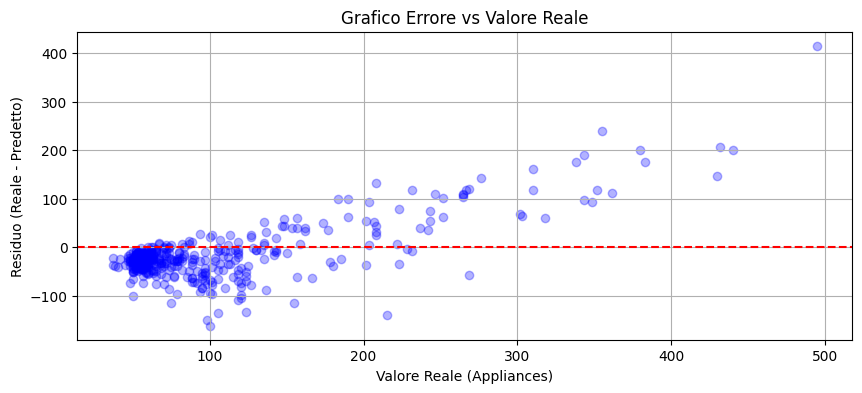

In [9]:
# ============================================================
# 9. ANALISI RESIDUI E DIAGNOSTICA PICCHI
# ============================================================
residuals = y_test_raw.values - pred_raw

plt.figure(figsize=(10, 4))
plt.scatter(y_test_raw, residuals, alpha=0.3, color="blue")
plt.axhline(0, color="red", linestyle="--")
plt.xlabel("Valore Reale (Appliances)")
plt.ylabel("Residuo (Reale - Predetto)")
plt.title("Grafico Errore vs Valore Reale")
plt.grid(True)
plt.show()
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

Grafico di dispersione
 Asse X:consumi reali 
Asse Y: errore di previsione o residuo (Reale - Predetto)
Linea dello 0: predizione perfetta (reale - predetto =0)

Dispersione: Se i punti si allargano man mano che il valore reale aumenta, significa che il modello è preciso sui bassi consumi (di routine), ma fa molta fatica a stimare l'entità dei picchi ad alto consumo (es. accensione simultanea di grandi elettrodomestici).

Punti sotto lo zero: Indicano casi in cui il modello ha sovrastimato il consumo.

Punti sopra lo zero: Indicano casi in cui il modello ha sottostimato il consumo.



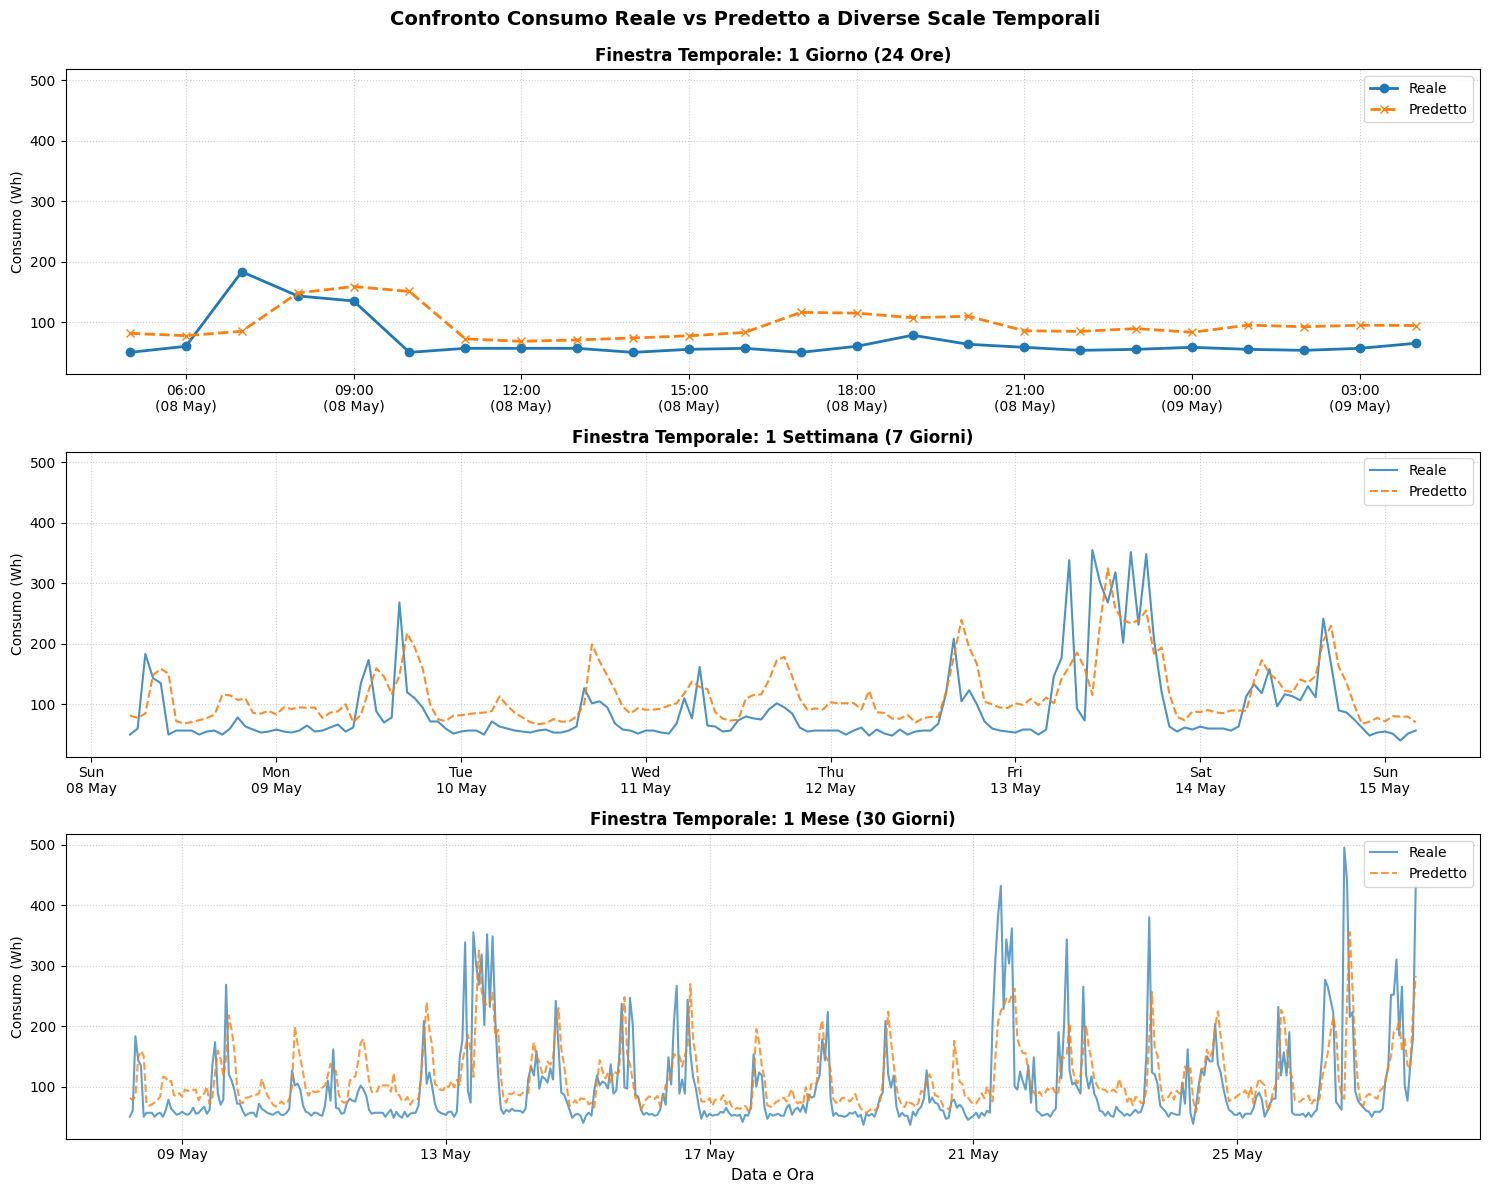

In [10]:
# ============================================================
# 10. FIGURA CON 3 SUBPLOT
# ============================================================
fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(15, 12), sharey=True)

# Recuperiamo tutte le date del Test Set
test_dates = df_model['date'].iloc[val_end:].reset_index(drop=True)

# ------------------------------------------------------------
# SCHEMA 1: FINESTRA DI 1 GIORNO (24 Ore)
# ------------------------------------------------------------
n_1day = 24
axes[0].plot(test_dates[:n_1day], y_test_raw.values[:n_1day], label="Reale", color="#1f77b4", marker="o", linewidth=2)
axes[0].plot(test_dates[:n_1day], pred_raw[:n_1day], label="Predetto", color="#ff7f0e", linestyle="--", marker="x", linewidth=2)

axes[0].set_title("Finestra Temporale: 1 Giorno (24 Ore)", fontsize=12, fontweight='bold')
axes[0].set_ylabel("Consumo (Wh)")
axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%H:%M\n(%d %b)'))
axes[0].grid(True, linestyle=":", alpha=0.6)
axes[0].legend(loc="upper right")

# ------------------------------------------------------------
# SCHEMA 2: FINESTRA DI 1 SETTIMANA (7 Giorni / 168 Ore)
# ------------------------------------------------------------
n_1week = 24 * 7
axes[1].plot(test_dates[:n_1week], y_test_raw.values[:n_1week], label="Reale", color="#1f77b4", alpha=0.8)
axes[1].plot(test_dates[:n_1week], pred_raw[:n_1week], label="Predetto", color="#ff7f0e", linestyle="--", alpha=0.9)

axes[1].set_title("Finestra Temporale: 1 Settimana (7 Giorni)", fontsize=12, fontweight='bold')
axes[1].set_ylabel("Consumo (Wh)")
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%a\n%d %b'))
axes[1].grid(True, linestyle=":", alpha=0.6)
axes[1].legend(loc="upper right")

# ------------------------------------------------------------
# SCHEMA 3: FINESTRA DI 1 MESE (30 Giorni / 720 Ore)
# ------------------------------------------------------------
n_1month = 24 * 30
axes[2].plot(test_dates[:n_1month], y_test_raw.values[:n_1month], label="Reale", color="#1f77b4", alpha=0.7)
axes[2].plot(test_dates[:n_1month], pred_raw[:n_1month], label="Predetto", color="#ff7f0e", linestyle="--", alpha=0.8)

axes[2].set_title("Finestra Temporale: 1 Mese (30 Giorni)", fontsize=12, fontweight='bold')
axes[2].set_xlabel("Data e Ora", fontsize=11)
axes[2].set_ylabel("Consumo (Wh)")
axes[2].xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))
axes[2].grid(True, linestyle=":", alpha=0.6)
axes[2].legend(loc="upper right")

# Formattazione e spaziatura
plt.suptitle("Confronto Consumo Reale vs Predetto a Diverse Scale Temporali", fontsize=14, fontweight='bold', y=0.99)
plt.tight_layout()
plt.show()

Come mostra l'altro grafico di dispersione, qui possiamo confermare che il modello tende a predirre sempre un po di più nei consumi bassi/di routine e di meno durante i picchi di consumo. 